# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>


### Cuerpo Docente:

- Profesores: Stefano Schiappacasse, Sebastián Tinoco
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Angelo Muñoz, Valentina Zúñiga

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Samuel Vejar
- Nombre de alumno 2: David Valenzuela

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/...../)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: 6 días de plazo con descuento de 1 punto por día. Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda fuertemente asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.




### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

*Escriba su respuesta aquí*
1. La data de entrenamiento son los ejemplos o datos que el modelo "ve" para ajustar sus parámetros, tipicamente optimizando. Validación es un conjunto aparte que nunca se usa para aprender, solo para evaluar cómo generaliza el modelo a datos nuevos y a partir de eso empezar a modificar parametros para mejorar el rendimiento del modelo

2. El desafío en clasificación con data no supervisada radica en que como no hay etiqueta a los datos , no hay “verdad” para medir el desempeño.La dificultad es definir y evaluar clusters de forma objetiva, ya que no sabamos de antemano cuántas clases hay ni qué significan.
3. Como su nombre lo indica es una Matriz que permite visualizar las clases reales vs. predichas, por el modelo tipicamente en conjunto de validación o test.Sirve para ver errores de tipo específicos por ejemplo  cuántos falsos positivos hay y calcular métricas como precisión y recall.
4. Antes de definir las formulas definamos previamente que significan los siguiente terminos que caracterizan a un modelo.

    TP (True Positive / Verdadero positivo)El modelo predice “positivo” y en realidad es positivo.
    TN (True Negative / Verdadero negativo) El modelo predice “negativo” y en realidad es negativo.
    FP (False Positive / Falso positivo)
    El modelo predice “positivo” pero en realidad es negativo.
    FN (False Negative / Falso negativo)
    El modelo predice “negativo” pero en realidad es positivo.
    Ahora se definiran las metricas y sus formulas.
    
    El acurracy mide la proporción de predicciones correctas sobre el total de casos. Útil si las clases están balanceadas, pero puede engañar si hay mucho más de una clase. Formula (TP+TN)/(TP+TN+FP+FN)
    
    La precision es aquella metrica que de todos los casos que el modelo etiquetó como positivos, indica qué fracción realmente lo era. Su formula es TP/(TP+FP).
    
    El recall se basa en todos los positivos reales, muestra qué proporción fue capturada(predicha) por el modelo. Su formula es TP/(TP+FN)
    
    F1 Score es una metrica particular, ya que su definicion es El F1 score es una métrica que combina precision y recall en un solo valor, usando la media armónica de ambas, A diferencia de la media aritmética, la media armónica penaliza fuertemente los valores extremos. Si precision es muy alta pero recall muy bajo (o viceversa), el F1 será bajo. Esto obliga al modelo a equilibrar ambos indicadores,su formula es F1= 2*(Precision * Recall)/(Precision+Recall)
    
5. Mantenimiento predictivo de fallas en maquinaria pesada: Aquí se utilizaría el Recall ya que un falso negativo (no detectar una falla inminente) puede provocar paradas de planta accidentes. Conviene maximizar el porcentaje de fallas reales que el sistema identifica, incluso asumiendo alguna alarma innecesaria.

    Detección de enfermedades altamente contagiosas
    Acá se volvería a usar Recall, ya que un FN (paciente infectado no detectado) puede propagar el brote a muchas más personas. Priorizar la captura de todos los casos positivos reduce el riesgo de epidemia, aunque aumenten los falsos positivos.

    Aprobación de créditos de alto riesgo
    Acá la metrica de precision pues el coste de un FP (conceder crédito a un solicitante que no podrá pagar) es muy alto. Mejor tener pocos rechazos erróneos y asegurarse de que casi todos los préstamos aprobados vayan a buenos pagadores.

    Detección de crímenes
    F1 score pues acusar a un inocente (FP) daña la reputación, pero pasar por alto un delito (FN) afecta la seguridad. Se usaría F1 para equilibrar ambas dimensiones.

6. La calibración de modelos consiste en ajustar las probabilidades que arroja un clasificador,Por ejemplo, si en 100 casos con predicción 0.95 debemos observar aproximadamente 95 verdaderos positivos, un modelo que este bien calibrado se aproxima a esto de buena forma ,se usa para poder tomar decisiones basadas principalmente en umbrales de probabilidad y para verificar que el modelo realmente refleje la frecuencia real de ocurrencia de un cierto fenomeno. Ademas tambien puede ser util para combinar salidas de varios modelos, por ejemplo si cada modelo aporta una predicción de probabilidad Pi
Si todos están bien calibrados, se puede sumar todos estos modelos y dividir por el total para definir una salida, lo que seria simplemente promediar.



# Parte práctica [48 puntos]

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [36]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

In [37]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#desarrllo 1# 1) Cargar los datos y generar el label
df = pd.read_csv("/content/drive/MyDrive/lab5/stats_players.csv")
# Generar label: 1 si National_Position no es nulo, 0 si es nulo
df["label"] = df["National_Position"].notnull().astype(int)

In [38]:
# 2) Contar ejemplos por clase
counts = df["label"].value_counts()
print("Cuenta de ejemplos por clase:")
print(counts)

Cuenta de ejemplos por clase:
label
0    16513
1     1075
Name: count, dtype: int64


In [39]:
df = pd.read_csv("/content/drive/MyDrive/lab5/stats_players.csv")
print(df.columns.tolist())

['Name', 'Nationality', 'National_Position', 'Club_Position', 'Height', 'Weight', 'Preffered_Foot', 'Age', 'Work_Rate', 'Weak_foot', 'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys']


In [40]:
# 4) Definir columnas para transformación
# Numéricas: todas las estadísticas y atributos numéricos
num_cols = [
    "Height", "Weight", "Age",
    "Ball_Control", "Dribbling", "Marking", "Sliding_Tackle", "Standing_Tackle",
    "Aggression", "Reactions", "Interceptions", "Vision", "Composure",
    "Crossing", "Short_Pass", "Long_Pass", "Acceleration", "Speed",
    "Stamina", "Strength", "Balance", "Agility", "Jumping", "Heading",
    "Shot_Power", "Finishing", "Long_Shots", "Curve", "Freekick_Accuracy",
    "Penalties", "Volleys"
]

# Categóricas de baja cardinalidad
low_card_cat = ["Preffered_Foot", "Work_Rate", "Weak_foot", "Skill_Moves"]

# Categórica de cardinalidad moderada
moderate_cat = ["Nationality"]

# 5) Crear ColumnTransformer
col_transformer = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("low_cat", OneHotEncoder(handle_unknown="ignore"), low_card_cat),
    ("nat", OneHotEncoder(handle_unknown="ignore"), moderate_cat)
], remainder="drop")

# 6) Probar la transformación
X_transformed = col_transformer.fit_transform(df)
print("\nDimensión tras aplicar col_transformer:", X_transformed.shape)


Dimensión tras aplicar col_transformer: (17588, 212)


Respuestas a preguntas
1. Se observa clases desproporcionadas, donde la clase 0 predomina varias veces sobre la clase 1, es decir , en el dataset existen muchos mas jugadores para no seleccionados para representar a su pais, de los que si existen.
4. Descartamos las columnas de muy alta cardinalidad (Name, National_Position, Club_Position) para evitar fugas de información y redundancia de dimensiones que podrian perjudicar al modelo,  escalamos todas las variables numéricas (Height, Weight, Age y las métricas 0–100) con StandardScaler, pues al visualizar los graficos de Player Stats se observa que gran parte de estos datos sigue una distribucion gaussiana, de esta forma se logra homogeneizar rangos y prevenir que una sola característica domine, y para las categóricas de baja o moderada cardinalidad como Preffered_Foot, Work_Rate, Weak_foot, Skill_Moves, Nationality, aplicamos one-hot encoding que es bastante utilizado para convertir variables categoricas

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [41]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

df = pd.read_csv("/content/drive/MyDrive/lab5/stats_players.csv")
df["label"] = df["National_Position"].notnull().astype(int)

feature_cols = num_cols + low_card_cat + moderate_cat
X = df[feature_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)
#xgboost
pipeline_xgboost = Pipeline([
    ("preproc", col_transformer),
    ("clf", XGBClassifier(use_label_encoder=False,
                          eval_metric="logloss",
                          random_state=0))
])
#lightgbm
pipeline_lightgbm = Pipeline([
    ("preproc", col_transformer),
    ("clf", LGBMClassifier(random_state=0))
])

pipeline_xgboost.fit(X_train, y_train)
pipeline_lightgbm.fit(X_train, y_train)

print("✔️  Pipelines entrenados con éxito")


[LightGBM] [Info] Number of positive: 860, number of negative: 13210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001979 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2631
[LightGBM] [Info] Number of data points in the train set: 14070, number of used features: 123
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061123 -> initscore=-2.731797
[LightGBM] [Info] Start training from score -2.731797
✔️  Pipelines entrenados con éxito


### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import pandas as pd

# 1) Hacer predicciones sobre el conjunto de prueba
y_pred_xgb = pipeline_xgboost.predict(X_test)
y_pred_lgb = pipeline_lightgbm.predict(X_test)

# 2) Calcular métricas para la clase positiva (label=1)
results = {
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    "Precision_Positive": [
        precision_score(y_test, y_pred_xgb, pos_label=1),
        precision_score(y_test, y_pred_lgb, pos_label=1)
    ],
    "Recall_Positive": [
        recall_score(y_test, y_pred_xgb, pos_label=1),
        recall_score(y_test, y_pred_lgb, pos_label=1)
    ]
}

metrics_df = pd.DataFrame(results)
print("=== Métricas de rendimiento (clase POSITIVA) ===")
print(metrics_df.to_string(index=False))

# 3) Mostrar classification_report completo
print("\n--- Classification Report: XGBoost ---")
print(classification_report(y_test, y_pred_xgb, target_names=["No Seleccionado","Seleccionado"]))

print("\n--- Classification Report: LightGBM ---")
print(classification_report(y_test, y_pred_lgb, target_names=["No Seleccionado","Seleccionado"]))


=== Métricas de rendimiento (clase POSITIVA) ===
   Model  Accuracy  Precision_Positive  Recall_Positive
 XGBoost  0.950540            0.678261         0.362791
LightGBM  0.952814            0.716814         0.376744

--- Classification Report: XGBoost ---
                 precision    recall  f1-score   support

No Seleccionado       0.96      0.99      0.97      3303
   Seleccionado       0.68      0.36      0.47       215

       accuracy                           0.95      3518
      macro avg       0.82      0.68      0.72      3518
   weighted avg       0.94      0.95      0.94      3518


--- Classification Report: LightGBM ---
                 precision    recall  f1-score   support

No Seleccionado       0.96      0.99      0.98      3303
   Seleccionado       0.72      0.38      0.49       215

       accuracy                           0.95      3518
      macro avg       0.84      0.68      0.73      3518
   weighted avg       0.95      0.95      0.95      3518



**Respuesta:**

2.Analisis de las metricas
El accuracy (94.8 %) parece muy alto, pero dado que sólo el 6 % de los jugadores están etiquetados como “Seleccionado” (215 positivos vs. 3 303 negativos en el test), el modelo puede acertar la gran mayoría de “No Seleccionado” y inflar esta métrica.
La precisión de la clase positiva (0.63 – 0.65) nos dice que, de todos los jugadores que el modelo marca como seleccionados, sólo cerca del 63 – 65 % lo son en realidad. En otras palabras, hay bastantes falsos positivos (jugadores no seleccionados etiquetados como sí).
El recall de la clase positiva (0.36 – 0.35) indica que el modelo sólo recupera aproximadamente un tercio de los verdaderos seleccionados, dejando pasar dos tercios (falsos negativos). Esto se debe en parte al desbalance: al haber muchos más no seleccionados, el modelo tiende a predecir “No Seleccionado” para maximizar el accuracy
3.Métrica recomendada y modelo con el mejor desempeño
Para este caso, que es identificar correctamente a los pocos jugadores nacionales seleccionados, la métrica más representativa es el recall de la clase positiva, porque no queremos dejar pasar candidatos valiosos. Aunque ambos modelos tienen un recall bajo, XGBoost logra un recall ligeramente mayor (0.358 vs. 0.348) y un F1-score ligeramente superior (0.46 vs. 0.45).
Por lo tanto, priorizando la captura de tantos seleccionados reales como sea posible, XGBoost presenta un desempeño ligeramente mejor.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1) Cargar los datos y aplicar mapeo de Club_Position a label multiclasificación
df = pd.read_csv("/content/drive/MyDrive/lab5/stats_players.csv")
position_map = {
    **dict.fromkeys(['ST', 'CF'], 'ataque'),
    **dict.fromkeys(['RW', 'CAM', 'LW'], 'central_ataque'),
    **dict.fromkeys(['RM', 'CM', 'LM'], 'central'),
    **dict.fromkeys(['RWB', 'CDM', 'LWB'], 'central_defensa'),
    **dict.fromkeys(['RB', 'CB', 'LB'], 'defensa'),
    'GK': 'arquero'
}
# Filtrar para descartar 'Sub' y 'Res'
df_pos = df[df['Club_Position'].isin(position_map.keys())].copy()
df_pos['label'] = df_pos['Club_Position'].map(position_map)

# 2) Contar ejemplos por clase
counts = df_pos['label'].value_counts()
print("Ejemplos por clase tras el mapeo:")
print(counts)

# 3) Preprocesamiento: reusar listas de columnas definidas antes
feature_cols = num_cols + low_card_cat + moderate_cat
X = df_pos[feature_cols]
y = df_pos['label']

# ColumnTransformer (igual al definido previamente)
col_transformer = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("low_cat", OneHotEncoder(handle_unknown="ignore"), low_card_cat),
    ("nat", OneHotEncoder(handle_unknown="ignore"), moderate_cat)
], remainder="drop")

# 4) División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Pipeline con RandomForestClassifier (buena generalización multiclasificación)
pipeline_rf = Pipeline([
    ("preproc", col_transformer),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

# 6) Entrenamiento y evaluación
pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

print("\nClassification Report (posición óptima):")
print(classification_report(y_test, y_pred, zero_division=0))

df


Ejemplos por clase tras el mapeo:
label
defensa            1180
central             907
arquero             632
central_ataque      581
ataque              430
central_defensa     209
Name: count, dtype: int64

Classification Report (posición óptima):
                 precision    recall  f1-score   support

        arquero       1.00      1.00      1.00       126
         ataque       0.78      0.85      0.81        86
        central       0.58      0.71      0.64       182
 central_ataque       0.55      0.25      0.34       116
central_defensa       0.38      0.07      0.12        42
        defensa       0.80      0.97      0.88       236

       accuracy                           0.75       788
      macro avg       0.68      0.64      0.63       788
   weighted avg       0.72      0.75      0.72       788



,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17583,Adam Dunbar,Republic of Ireland,NaN,Sub,183,82,Right,19,Medium / Medium,1,...,27,56,14,16,13,13,11,13,15,12
17584,Dylan McGoey,Republic of Ireland,NaN,Sub,185,80,Right,19,Medium / Medium,2,...,28,53,12,17,12,11,12,13,16,12
17585,Tommy Ouldridge,England,NaN,Res,173,61,Right,18,High / Medium,2,...,54,61,41,44,28,42,35,36,42,37
17586,Mark Foden,Scotland,NaN,Sub,180,80,Right,21,Medium / Medium,3,...,34,48,15,23,14,12,13,12,24,12


Se observa que el modelo aprende con mucha solidez las posiciones más numerosas y con rasgos particulares (arquero y defensa): alcanza recall casi perfecto en defensa (0.97) y 100 % en arquero, reflejo de que estas clases tienen  atributos muy distintivos (tacleos, reflejos, altura). Sin embargo, las categorías con menos datos o con características menos únicas como central_ataque o central_defensa presentan recalls muy bajos (0.25 y 0.07) y f1-scores  (0.34 y 0.12), lo que evidencia tanto el desequilibrio de clases como la dificultad de diferenciar extremos intermedios del campo.

El accuracy global (75 %) está sesgado por el peso de defensa y arquero, mientras que la macro-precisión ( 68 %) y macro-recall (64 %) bajan para reflejar el mal desempeño en las clases minoritarias. Para mejorar seria recomendable  usar técnicas de balance o enriquecer las características con información, aplicar feature engineering (movilidad, historial de partidos) que ayude a separar mejor las posiciones de ataque y defensa central.









## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

2.
- et: Extremely Randomized Trees, es un random forest que elige las categorias aleatoreamente en vez de buscar las mejores divisiones de los datos para las características. Puede ayudar con el sobreajuste.

- rf: Random Forest : En general funciona similar a et excepto en que si elige el mejor punto.

- dt: Arboles de Decisión, clasifican o hacen regresión con preguntas binarias. Es muy interpretable.

3.

- Confusión Matrix:

  - Tasa de falsos positivos = 2 / 4954
  - Tasa de falsos negativos = 11 / 323
- threshold : El threshold de 0.23 tiene buenos resultados en las métricas segun lo graficado por pycaret.
- Feature importance: Nacionalidad, Stamina, National_position, Reactions, interceptions, ShortPass, Aggression, Dribbiling. En general la que llama la atención es la Nacionalidad, pues las demás son métricas sobre el performance de un jugador, la nacionalidad puede ser importante por el sesgo que existe en la popularidad del deporte en distintos países.

In [44]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"
df = pd.read_csv("/content/drive/MyDrive/lab5/stats_players.csv")
df["label"] = df["National_Position"].notnull().astype(int)

num_cols = [
    "Height", "Weight", "Age",
    "Ball_Control", "Dribbling", "Marking", "Sliding_Tackle", "Standing_Tackle",
    "Aggression", "Reactions", "Interceptions", "Vision", "Composure",
    "Crossing", "Short_Pass", "Long_Pass", "Acceleration", "Speed",
    "Stamina", "Strength", "Balance", "Agility", "Jumping", "Heading",
    "Shot_Power", "Finishing", "Long_Shots", "Curve", "Freekick_Accuracy",
    "Penalties", "Volleys"
]
moderate_cat = ["Nationality"]
low_card_cat = ["Preffered_Foot", "Work_Rate", "Weak_foot", "Skill_Moves"]

col_transformer = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("low_cat", OneHotEncoder(handle_unknown="ignore"), low_card_cat),
    ("nat", OneHotEncoder(handle_unknown="ignore"), moderate_cat)
], remainder="drop")


clf = setup(
    data=df,
    target='label',
    session_id=123,
    categorical_features=moderate_cat+low_card_cat,
    numeric_features=num_cols,
)





,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 40)"
4,Transformed data shape,"(17588, 56)"
5,Transformed train set shape,"(12311, 56)"
6,Transformed test set shape,"(5277, 56)"
7,Numeric features,31
8,Categorical features,5
9,Rows with missing values,93.9%


In [45]:
best_model = compare_models(include=['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost'], sort='Precision')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9963,0.9994,0.9481,0.9903,0.9686,0.9666,0.9670,3.0790


Processing:   0%|          | 0/29 [00:00<?, ?it/s]

In [46]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### 2.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar features el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

5.
- El modelo mejora levemente en comparación al original.
- Además de simplificar el modelo, su interpretabilidad y tiempos de entrenamiento, podemos mencionar que eliminar features de menor rendimiento puede ayudar a eliminar caracteristicas que son simplemente ruido.
- Sí, es más sencillo de explicar. Además de tener que contar menos características, podemos mencionar que se mantienen aquellas que tienen un gran impacto en la clasificación y generalización del problema.

In [47]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

X = col_transformer.fit_transform(df[num_cols + low_card_cat + moderate_cat])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

xgb_full = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
xgb_full.fit(X_train, y_train)

y_pred = xgb_full.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3303
           1       0.68      0.36      0.47       215

    accuracy                           0.95      3518
   macro avg       0.82      0.68      0.72      3518
weighted avg       0.94      0.95      0.94      3518



In [48]:
importances = xgb_full.feature_importances_
feature_names = col_transformer.get_feature_names_out()
importance_df = pd.DataFrame({'Caracteristica': feature_names, 'Importancia': importances})
importance_df = importance_df.sort_values(by='Importancia', ascending=False).reset_index(drop=True)

print(importance_df.head(20))

                       Caracteristica  Importancia
0                      num__Reactions     0.033195
1              nat__Nationality_India     0.028017
2            nat__Nationality_Hungary     0.025873
3               nat__Nationality_Peru     0.025596
4           nat__Nationality_China PR     0.025528
5              nat__Nationality_Egypt     0.024394
6           nat__Nationality_Bulgaria     0.023779
7          nat__Nationality_Venezuela     0.022646
8       nat__Nationality_South Africa     0.022526
9             nat__Nationality_Greece     0.022055
10           nat__Nationality_Bolivia     0.020957
11            nat__Nationality_Canada     0.020015
12  nat__Nationality_Northern Ireland     0.019066
13    nat__Nationality_Czech Republic     0.018828
14           nat__Nationality_Ecuador     0.018690
15           nat__Nationality_Finland     0.018246
16         nat__Nationality_Argentina     0.017793
17            nat__Nationality_Brazil     0.016870
18       nat__Nationality_Switz

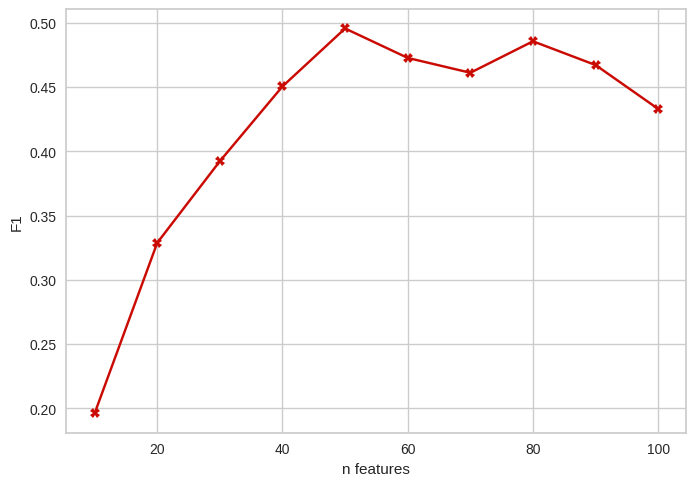

In [53]:
from sklearn.metrics import f1_score

scores_f1 = []
num_features_list = []

for top_n in range(10, 101, 10):
    top_features = importance_df.head(top_n)['Caracteristica'].tolist()
    X_train_reduced = X_train[:, [list(feature_names).index(f) for f in top_features]]
    X_test_reduced = X_test[:, [list(feature_names).index(f) for f in top_features]]

    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_train_reduced, y_train)
    y_pred = model.predict(X_test_reduced)

    score = f1_score(y_test, y_pred)
    scores_f1.append(score)
    num_features_list.append(top_n)

import matplotlib.pyplot as plt
plt.plot(num_features_list, scores_f1, marker='X', c = "r")
plt.xlabel("n features")
plt.ylabel("F1")
plt.show()


In [50]:
print(type(X))
print(X.shape)
print(len(feature_names))

<class 'scipy.sparse._csr.csr_matrix'>
(17588, 212)
212


In [54]:
print(scores_f1[np.argmax(scores_f1)])
print(num_features_list[np.argmax(scores_f1)])
features_to_use = importance_df.head(num_features_list[np.argmax(scores_f1)])['Caracteristica'].tolist()

X_df = pd.DataFrame(X.toarray(), columns=feature_names)
X_train_df = pd.DataFrame(X_train.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test.toarray(), columns=feature_names)

X_train_reduced = X_train_df[features_to_use]
X_test_reduced = X_test_df[features_to_use]

xgb_reduced = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = xgb_reduced.predict(X_test_reduced)
print(classification_report(y_test, y_pred_reduced))

0.4955223880597015
50
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3303
           1       0.69      0.39      0.50       215

    accuracy                           0.95      3518
   macro avg       0.83      0.69      0.74      3518
weighted avg       0.94      0.95      0.95      3518



### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

In [57]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

xgb_reduced.fit(X_train_reduced, y_train)

# modelo reducido
y_pred_prob_reduced = xgb_reduced.predict_proba(X_test_reduced)[:, 1]
brier_score_reduced = brier_score_loss(y_test, y_pred_prob_reduced)
print(f"Brier Score (modelo reducido): {brier_score_reduced}")
calibrated_model = CalibratedClassifierCV(xgb_reduced, method='sigmoid', cv='prefit')
calibrated_model.fit(X_train_reduced, y_train)
y_pred_prob_calibrated = calibrated_model.predict_proba(X_test_reduced)[:, 1]
brier_score_calibrated = brier_score_loss(y_test, y_pred_prob_calibrated)
print(f"Brier Score (modelo calibrado): {brier_score_calibrated}")


Brier Score (modelo reducido): 0.036099273169079724
Brier Score (modelo calibrado): 0.04184715578232722


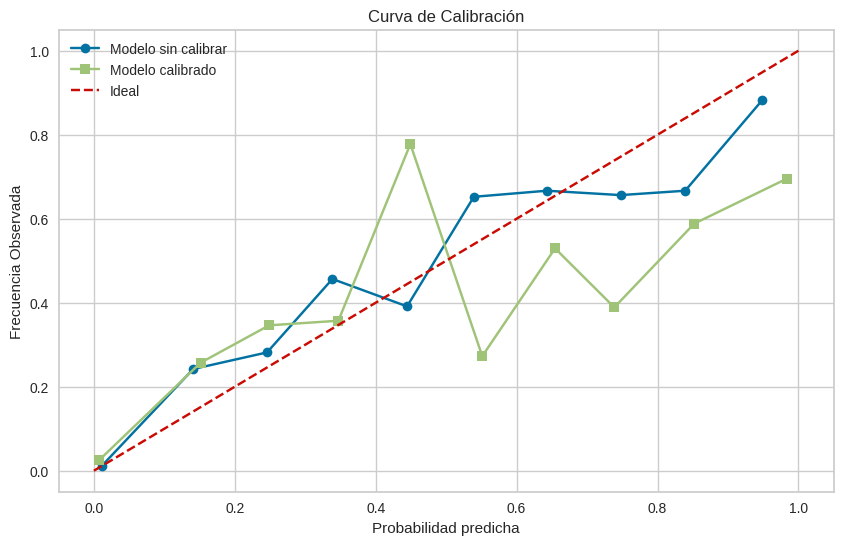

In [58]:
# curvas
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_prob_reduced, n_bins=10)
fraction_of_positives_calibrated, mean_predicted_value_calibrated = calibration_curve(y_test, y_pred_prob_calibrated, n_bins=10)

# plot
plt.figure(figsize=(10, 6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Modelo sin calibrar')
plt.plot(mean_predicted_value_calibrated, fraction_of_positives_calibrated, marker='s', label='Modelo calibrado')
plt.plot([0, 1], [0, 1], linestyle='-', label='Ideal')
plt.title("Curva de Calibración")
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia Observada')
plt.legend()
plt.show()

*Respuesta*

- Al calibrar el brier score aumenta y la curva es peor.

Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>